Analyzing House Rent Prediction
-

The spectrum of housing options in India is incredibly diverse, spanning from the opulent palaces once inhabited by maharajas of yore, to the contemporary high-rise apartment complexes in bustling metropolitan areas, and even to the humble abodes in remote villages, consisting of modest huts. This wide-ranging tapestry of residential choices reflects the significant expansion witnessed in India's housing sector, which has paralleled the upward trajectory of income levels in the country. According to the findings of the Human Rights Measurement Initiative, India currently achieves 60.9% of what is theoretically attainable, considering its current income levels, in ensuring the fundamental right to housing for its citizens. In the realm of housing arrangements, renting, known interchangeably as hiring or letting, constitutes an agreement wherein compensation is provided for the temporary utilization of a resource, service, or property owned by another party. Within this arrangement, a gross lease is one where the tenant is obligated to pay a fixed rental amount, and the landlord assumes responsibility for covering all ongoing property-related expenses. The concept of renting also aligns with the principles of the sharing economy, as it fosters the utilization of assets and resources among individuals or entities, promoting efficiency and access to housing solutions for a broad spectrum of individuals.


Importing Libaries and Dataset
-

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

from xgboost import XGBRegressor

# Reading the Dataset

In [43]:
rent_pred = pd.read_csv('../Dataset/House_Rent_Dataset.csv')

rent_pred.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


# Shape of the Dataset

In [44]:
rent_pred.shape

(4746, 12)

# Exploring the Dataset

In [45]:
print(rent_pred.info())
rent_pred.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB
None


,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


# Creating Interactive Features

In [46]:
rent_pred['rent_per_sqft'] = rent_pred['Rent'] / rent_pred['Size']
rent_pred['size_per_bhk'] = rent_pred['Size'] / rent_pred['BHK']
rent_pred['rent_per_bhk'] = rent_pred['Rent'] / rent_pred['BHK']
rent_pred['rent_per_bathroom'] = rent_pred['Rent'] / rent_pred['Bathroom']
rent_pred['size_per_bathroom'] = rent_pred['Size'] / rent_pred['Bathroom']

In [47]:
rent_pred.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,rent_per_sqft,size_per_bhk,rent_per_bhk,rent_per_bathroom,size_per_bathroom
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,9.090909,550.0,5000.0,5000.0,550.0
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,25.000000,400.0,10000.0,20000.0,800.0
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,17.000000,500.0,8500.0,17000.0,1000.0
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,12.500000,400.0,5000.0,10000.0,800.0
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,8.823529,425.0,3750.0,7500.0,850.0


In [48]:
rent_pred.describe()

,BHK,Rent,Size,Bathroom,rent_per_sqft,size_per_bhk,rent_per_bhk,rent_per_bathroom,size_per_bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000,4746.000000,4746.000000,4.746000e+03,4.746000e+03,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866,39.257087,458.454263,1.500151e+04,1.515582e+04,493.309501
std,0.832256,7.810641e+04,634.202328,0.884532,59.855230,211.596397,2.454189e+04,2.369863e+04,207.499637
min,1.000000,1.200000e+03,10.000000,1.000000,0.571429,3.333333,4.000000e+02,4.000000e+02,3.333333
25%,2.000000,1.000000e+04,550.000000,1.000000,13.333333,350.000000,6.000000e+03,6.500000e+03,375.000000
50%,2.000000,1.600000e+04,850.000000,2.000000,20.000000,450.000000,8.333333e+03,9.500000e+03,483.333333
75%,3.000000,3.300000e+04,1200.000000,2.000000,42.005986,550.000000,1.600000e+04,1.666667e+04,600.000000
max,6.000000,3.500000e+06,8000.000000,10.000000,1500.000000,8000.000000,1.166667e+06,1.166667e+06,2160.000000


# Checking for Missing Values

In [49]:
rent_pred.isnull().sum().sort_values(ascending=False)

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
rent_per_sqft        0
size_per_bhk         0
rent_per_bhk         0
rent_per_bathroom    0
size_per_bathroom    0
dtype: int64

# Data Visualization

Taking a look at the rent of houses in different cities acording to the number of bedroom, halls and kitchens 

In [50]:
figure = px.bar(rent_pred, x=rent_pred['City'],
                y=rent_pred['Rent'],
                color=rent_pred['BHK'],
                title="Rent in Different Cities According to BHK",
)

figure.show()

Rent in different cities according to Area Type

In [51]:
figure = px.bar(rent_pred, x=rent_pred['City'],
                y=rent_pred['Rent'],
                color=rent_pred['Area Type'],
                title="Rent in Different Cities According to Area Type"
)

figure.show()

Rent in Different Cities According to Furnishing Status

In [52]:
figure = px.bar(rent_pred, x=rent_pred['City'],
                y=rent_pred['Rent'],
                color=rent_pred['Furnishing Status'],
                title="Rent in Different Cities According to Area Furnishing Status"
)

figure.show()

Rent of Houses in Different Cities According to Size

In [53]:
figure = px.bar(rent_pred, x=rent_pred['City'],
                y=rent_pred['Rent'],
                color=rent_pred['Size'],
                title="Rent in Different Cities According to Size"
)

figure.show()

Number of Houses available for Rent in different Cities

In [54]:
cities = rent_pred['City'].value_counts()
label = cities.index
counts = cities.values
colors = ['green', 'blue']

fig = go.Figure(data=[go.Pie(labels=label, values=counts, hole=0.5)])
fig.update_layout(title_text='Number of Houses Available for Rent')
fig.update_traces(hoverinfo='label+percent', textinfo='value', marker=dict(colors=colors))

fig.show()

Number of Houses Available with Preferred type of Tenant

In [55]:
tenant = rent_pred['Tenant Preferred'].value_counts()
label = tenant.index
counts = tenant.values
colors = ['green', 'blue']

fig = go.Figure(data=[go.Pie(labels=label, values=counts, hole=0.5)])
fig.update_layout(title_text='Preference of Tenant in India')
fig.update_traces(hoverinfo='label+percent', textinfo='value', marker=dict(colors=colors))

fig.show()

# Correlation Plot

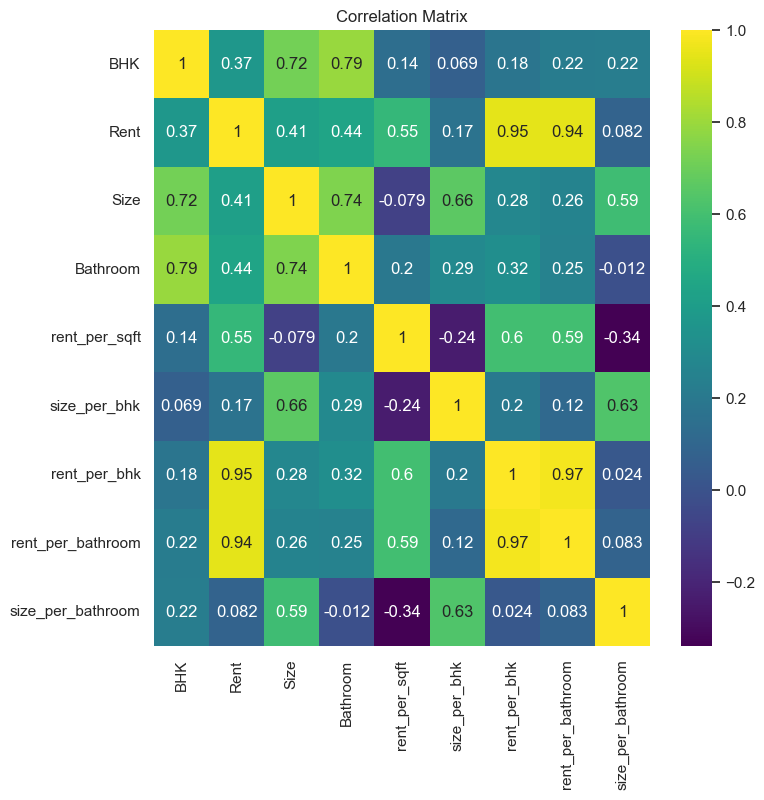

In [56]:
corr_matrix = rent_pred.select_dtypes(include='number').corr()

plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, cmap='viridis')
plt.title('Correlation Matrix')
plt.show()

# Handling Categorical Features

# Data Preprocessing

Encoding categorical features to numerical features so we can train our house rent prediction model

OneHotEncoding

In [57]:
rent_pred = pd.get_dummies(rent_pred, columns=['City', 'Furnishing Status', 'Area Type', 'Tenant Preferred'], dtype=int, drop_first=True)

In [58]:
rent_pred.head()

,Posted On,BHK,Rent,Size,Floor,Area Locality,Bathroom,Point of Contact,rent_per_sqft,size_per_bhk,...,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Area Type_Carpet Area,Area Type_Super Area,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family
0,2022-05-18,2,10000,1100,Ground out of 2,Bandel,2,Contact Owner,9.090909,550.0,...,0,0,1,0,0,1,0,1,1,0
1,2022-05-13,2,20000,800,1 out of 3,"Phool Bagan, Kankurgachi",1,Contact Owner,25.000000,400.0,...,0,0,1,0,1,0,0,1,1,0
2,2022-05-16,2,17000,1000,1 out of 3,Salt Lake City Sector 2,1,Contact Owner,17.000000,500.0,...,0,0,1,0,1,0,0,1,1,0
3,2022-07-04,2,10000,800,1 out of 2,Dumdum Park,1,Contact Owner,12.500000,400.0,...,0,0,1,0,0,1,0,1,1,0
4,2022-05-09,2,7500,850,1 out of 2,South Dum Dum,1,Contact Owner,8.823529,425.0,...,0,0,1,0,0,1,1,0,0,0


# Feature Selection and Data Splitting

In [59]:
X = rent_pred.drop(columns=['Rent', 'Posted On', 'Floor', 'Area Locality', 'Point of Contact'], axis=1)
y = rent_pred['Rent']

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling

Since features are on different scales we apply standardization to improve model performance. It prevents models from being biased toward larger numerical values and improves convergence speed in optimization algorithms like gradient descent

In [61]:
ss = StandardScaler()

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

# Model Training, Prediction and Evaluation


# Linear Regression

In [62]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print('Linear Regression Predictions:', y_pred)

Linear Regression Predictions: [ 1.99455861e+04  7.27227261e+03  2.02208320e+04  2.12937941e+04
  7.64597609e+04  1.36954914e+04  5.73127937e+04  8.95319203e+03
  3.17765948e+05  1.52251170e+04  3.84503938e+03  8.15168845e+03
  2.87493021e+04  1.77558999e+04  2.35885712e+04 -1.76507463e+04
  1.37979132e+05  1.09189283e+04  1.72603012e+03  6.93549601e+04
  4.68805305e+04 -3.25329191e+03  2.36523136e+04  6.03769266e+03
  2.30808051e+05 -2.62380743e+03 -8.93905329e+03  2.86901334e+04
 -5.73219443e+03  1.25858531e+04 -5.99723984e+03  1.85435555e+04
  7.97589099e+03  7.73418234e+03  3.33789759e+04  3.50129464e+04
  5.54743263e+03 -8.34801407e+03  1.86798963e+04  6.71761721e+03
  1.05164549e+04  2.55155204e+05  1.00157544e+04 -5.66241935e+03
  7.04372159e+04  1.24927736e+04  2.60490246e+04  7.06366795e+04
  2.77834209e+05  1.18885945e+04  1.02624383e+04  4.09535275e+04
  1.54154404e+04  1.83800199e+04  7.69509585e+04  1.11772114e+05
  4.54720599e+04  3.62232755e+04 -7.41939374e+03  2.2592674

In [63]:
print('Model Score: ', lr.score(X_test, y_test))

Model Score:  0.9304947092169861


Evaluation

In [64]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Baseline Linear Regression: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}')

Baseline Linear Regression: MAE=8998.97, RMSE=16643.47, R2=0.93


Cross Validation

In [65]:
cv_scores = cross_val_score(lr, X, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)
print(f'CV RMSE: {cv_rmse.mean():.2f} +- {cv_rmse.std():.2f}')

CV RMSE: 17561.43 +- 6345.46


# RandomForestRegressor

In [66]:
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train, y_train)
y_pred = rfr.predict(X_test)
print("Random Forest Regressor Predictions:", y_pred)

Random Forest Regressor Predictions: [ 16000.    12000.    28060.     7869.    49014.98  17000.    56655.
   9500.   383100.    15000.    10000.    12000.    27005.    15995.
  15000.     8500.   142500.    12000.     5972.    60000.    38300.
   7500.    23049.99  14000.   258300.     5000.     6000.    16635.
   6500.    15000.     5000.    14000.     4992.    12000.    24935.
  25000.     7500.     6000.    17000.     7000.    13000.   298100.
  14000.     6000.    60000.    14000.    32000.    69890.   336400.
  15000.    11000.    35000.    18000.    12000.    65180.   128700.
  35000.    40000.     9000.     9000.    18000.     5000.   135200.
  12000.    50000.    20000.    18000.    15370.    35015.    30000.
  13000.    23945.   101100.     7000.    25000.    35000.    12000.
  57685.    35000.    28035.    14000.    10000.    34539.95  10000.
  12000.    45000.    35993.75  18000.    25000.    26800.   261300.
  35000.    23999.83 120100.    13000.    12315.    11000.     700

In [67]:
print("Model Score: ", rfr.score(X_test, y_test))

Model Score:  0.9506575584787491


Evaluation

In [68]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Baseline RandomForest: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}')

Baseline RandomForest: MAE=1077.77, RMSE=14023.14, R2=0.95


Cross Validation

In [69]:
cv_scores = cross_val_score(rfr, X, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)
print(f'CV RMSE: {cv_rmse.mean():.2f} +- {cv_rmse.std():.2f}')

CV RMSE: 28536.36 +- 33835.40


# XGBRegressor

In [70]:
xgb = XGBRegressor(eval_metric='rmse', random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
print('XGBRegressor Prediction:', y_pred)

XGBRegressor Prediction: [ 15995.223   12087.283   27571.3      6398.6177  49207.605   16966.332
  58330.14     9618.748  394011.94    15029.144    9963.457   12111.532
  26976.418   16353.936   14977.103    8487.814  141713.36    12091.943
   6019.564   59915.984   38207.645    7499.5674  22539.965   13958.724
 251787.22     5042.084    5954.2407  16299.851    6463.5654  14766.825
   4970.731   13949.307    4329.935   12092.576   26803.727   24938.24
   7446.4653   5953.452   16975.602    7098.1445  12996.776  303093.6
  13956.748    5954.2407  60249.273   13963.428   31431.176   73505.97
 357923.      15038.471   10914.13    35048.844   18004.309   11663.987
  65073.094  129331.945   35194.234   40091.535    9016.115    8809.12
  18011.143    4973.3843 124519.09    11854.59    50272.734   20011.977
  17771.361   15161.268   34869.59    30541.451   13110.68    24207.797
 100101.02     7105.583   24975.357   35004.355   12081.457   55221.973
  35157.188   27632.32    13970.143    9944.

In [71]:
print("Model Score:", xgb.score(X_test, y_test))

Model Score: 0.8842769265174866


Evaluation

In [72]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Baseline XGBRegressor: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}')

Baseline XGBRegressor: MAE=1505.90, RMSE=21475.58, R2=0.88


Cross Validation

In [73]:
cv_scores = cross_val_score(xgb, X, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)
print(f'CV RMSE: {cv_rmse.mean():.2f} +- {cv_rmse.std():.2f}')

CV RMSE: 41442.83 +- 39262.32


# Pipeline and Model Tuning
Using a `Pipeline` so scaling is applied inside cross-validation, then tune the best model (`RandomForestRegressor`). This gives a reliable production-style workflow.

In [74]:
pipe = Pipeline([
    ('model', RandomForestRegressor(random_state=42))
])

pipe_cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
print(f'Pipeline CV RMSE: {np.sqrt(-pipe_cv_scores).mean():.2f} +- {np.sqrt(-pipe_cv_scores).std():.2f}')

Pipeline CV RMSE: 28536.36 +- 33835.40


In [75]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print('Best parameters:', grid.best_params_)
print('Best CV RMSE:', np.sqrt(-grid.best_score_))

best_pipe = grid.best_estimator_
y_pred_best = best_pipe.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)
print(f'Best tuned pipeline test MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best CV RMSE: 48880.977030417685
Best tuned pipeline test MAE=1630.78, RMSE=16957.22, R2=0.9278


### Log-transform the rent target
Because rent is skewed, you can also try `np.log1p(Rent)` for training and inverse-transform predictions with `np.expm1`.

In [76]:
y_log = np.log1p(y)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

pipe_log = Pipeline([
    ('model', RandomForestRegressor(random_state=42))
])

pipe_log.fit(X_train_log, y_train_log)
y_pred_log = np.expm1(pipe_log.predict(X_test_log))
mae_log = mean_absolute_error(np.expm1(y_test_log), y_pred_log)
rmse_log = np.sqrt(mean_squared_error(np.expm1(y_test_log), y_pred_log))
r2_log = r2_score(np.expm1(y_test_log), y_pred_log)
print(f'Log-target RandomForest: MAE={mae_log:.2f}, RMSE={rmse_log:.2f}, R2={r2_log:.4f}')

Log-target RandomForest: MAE=788.94, RMSE=9095.06, R2=0.9792


#

✓ Histogram saved to '../Notebook/models_metrics_histogram.png'


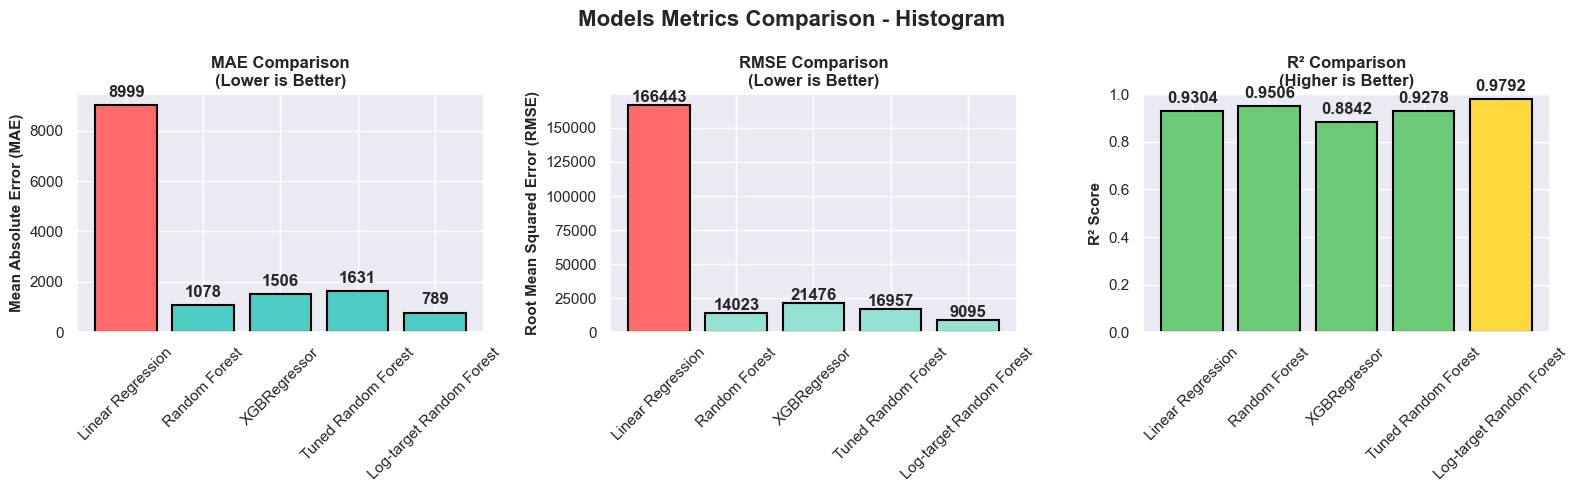

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Model metrics collected from the notebook
models_metrics = {
    'Linear Regression': {
        'MAE': 8998.97,
        'RMSE': 166443.47,
        'R2': 0.9304
    },
    'Random Forest': {
        'MAE': 1077.77,
        'RMSE': 14023.14,
        'R2': 0.9506
    },
    'XGBRegressor': {
        'MAE': 1505.90,
        'RMSE': 21475.58,
        'R2': 0.8842
    },
    'Tuned Random Forest': {
        'MAE': 1630.78,
        'RMSE': 16957.22,
        'R2': 0.9278
    },
    'Log-target Random Forest': {
        'MAE': 788.94,
        'RMSE': 9095.06,
        'R2': 0.9792
    }
}

# Extract metrics
model_names = list(models_metrics.keys())
mae_values = [models_metrics[m]['MAE'] for m in model_names]
rmse_values = [models_metrics[m]['RMSE'] for m in model_names]
r2_values = [models_metrics[m]['R2'] for m in model_names]

# Create subplots for each metric
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Models Metrics Comparison - Histogram', fontsize=16, fontweight='bold')

# MAE histogram
colors_mae = ['#FF6B6B' if v == max(mae_values) else '#4ECDC4' for v in mae_values]
axes[0].bar(model_names, mae_values, color=colors_mae, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Mean Absolute Error (MAE)', fontsize=11, fontweight='bold')
axes[0].set_title('MAE Comparison\n(Lower is Better)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(mae_values):
    axes[0].text(i, v + 200, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

# RMSE histogram
colors_rmse = ['#FF6B6B' if v == max(rmse_values) else '#95E1D3' for v in rmse_values]
axes[1].bar(model_names, rmse_values, color=colors_rmse, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Root Mean Squared Error (RMSE)', fontsize=11, fontweight='bold')
axes[1].set_title('RMSE Comparison\n(Lower is Better)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(rmse_values):
    axes[1].text(i, v + 200, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

# R2 histogram
colors_r2 = ['#FFD93D' if v == max(r2_values) else '#6BCB77' for v in r2_values]
axes[2].bar(model_names, r2_values, color=colors_r2, edgecolor='black', linewidth=1.5)
axes[2].set_ylabel('R² Score', fontsize=11, fontweight='bold')
axes[2].set_title('R² Comparison\n(Higher is Better)', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylim([0, 1])
for i, v in enumerate(r2_values):
    axes[2].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../Notebook/models_metrics_histogram.png', dpi=300, bbox_inches='tight')
print("✓ Histogram saved to '../Notebook/models_metrics_histogram.png'")
plt.show()